<a href="https://colab.research.google.com/github/Ibrahimtech821/crypto_currency/blob/BNB_SOL/BNB_SOL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [128]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from google.colab import files

# Define symbols
symbols = ["BNB-USD", "SOL-USD"]

for symbol in symbols:
    print(f"Fetching {symbol}...")

    # Fetch 6 years of daily data
    # Note: SOL-USD only has data going back to 2020, so it will fetch from its start date automatically.
    df = yf.download(symbol, period="6y", interval="1d")

    if not df.empty:
        # 1. Clean up the filename (e.g., 'bnb_6year_data.csv')
        filename = f"{symbol.lower().replace('-','_')}_6years.csv"

        # 2. Save the file to the Colab environment
        df.to_csv(filename)
        print(f"  Successfully saved: {filename}")

        # 3. Trigger a browser download to your local computer
        files.download(filename)
    else:
        print(f"  No data found for {symbol}")

print("\nAll tasks complete. Check your 'Downloads' folder!")

/tmp/ipykernel_499/3744936009.py:17: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Fetching BNB-USD...
  Successfully saved: bnb_usd_6years.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Fetching SOL-USD...


/tmp/ipykernel_499/3744936009.py:17: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


  Successfully saved: sol_usd_6years.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All tasks complete. Check your 'Downloads' folder!


In [129]:
df4 = pd.read_csv('bnb_usd_6years.csv')
df4.head(3)

,Price,Close,High,Low,Open,Volume
0,Ticker,BNB-USD,BNB-USD,BNB-USD,BNB-USD,BNB-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-03-24,12.401220321655273,12.5714111328125,11.850914001464844,12.116397857666016,333522129


In [130]:
df5 = pd.read_csv('sol_usd_6years.csv')
df5.head(3)

,Price,Close,High,Low,Open,Volume
0,Ticker,SOL-USD,SOL-USD,SOL-USD,SOL-USD,SOL-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-04-10,0.9510539770126343,1.3134870529174805,0.6941869854927063,0.8320050239562988,87364276


In [131]:
df4.columns = df4.columns.str.lower()
df5.columns = df5.columns.str.lower()

In [132]:
df4 = df4.iloc[2:].reset_index(drop=True)
df5 = df5.iloc[2:].reset_index(drop=True)

In [133]:
df4 = df4.rename(columns={'price': 'date'})
df5 = df5.rename(columns={'price': 'date'})
df4['type'] = 'BNB'
df5['type'] = 'SOL'
df4['quote_volume'] = df4['volume'].astype(float) * df4['close'].astype(float)
df5['quote_volume'] = df5['volume'].astype(float) * df5['close'].astype(float)

In [134]:
df4.head(3)

,date,close,high,low,open,volume,type,quote_volume
0,2020-03-24,12.401220321655273,12.5714111328125,11.850914001464844,12.116397857666016,333522129,BNB,4.136081e+09
1,2020-03-25,12.324299812316895,12.6304931640625,12.119498252868652,12.403792381286621,288895593,BNB,3.560436e+09
2,2020-03-26,13.217611312866211,13.217611312866211,12.26111888885498,12.325833320617676,299218749,BNB,3.954957e+09


In [135]:
df5.head(3)

,date,close,high,low,open,volume,type,quote_volume
0,2020-04-10,0.9510539770126343,1.3134870529174805,0.6941869854927063,0.8320050239562988,87364276,SOL,8.308814e+07
1,2020-04-11,0.7768189907073975,1.0490729808807373,0.7650200128555298,0.9510539770126343,43862444,SOL,3.407318e+07
2,2020-04-12,0.8825070261955261,0.9566699862480164,0.7624260187149048,0.7854480147361755,38736897,SOL,3.418558e+07


In [136]:
df4.isna().sum()

,0
date,0
close,0
high,0
low,0
open,0
volume,0
type,0
quote_volume,0


In [137]:
df5.isna().sum()

,0
date,0
close,0
high,0
low,0
open,0
volume,0
type,0
quote_volume,0


In [138]:
print(df4['date'].value_counts())
df4.duplicated(subset='date').sum()

date
2026-03-24    1
2020-03-24    1
2020-03-25    1
2020-03-26    1
2020-03-27    1
             ..
2020-04-12    1
2020-04-11    1
2020-04-10    1
2020-04-09    1
2020-04-08    1
Name: count, Length: 2191, dtype: int64


np.int64(0)

In [139]:
print(df5['date'].value_counts())
df5.duplicated(subset='date').sum()

date
2026-03-24    1
2020-04-10    1
2020-04-11    1
2020-04-12    1
2020-04-13    1
             ..
2020-04-28    1
2020-04-27    1
2020-04-26    1
2020-04-25    1
2020-04-24    1
Name: count, Length: 2174, dtype: int64


np.int64(0)

# **Visualization**

/tmp/ipykernel_499/2394801177.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_499/2394801177.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




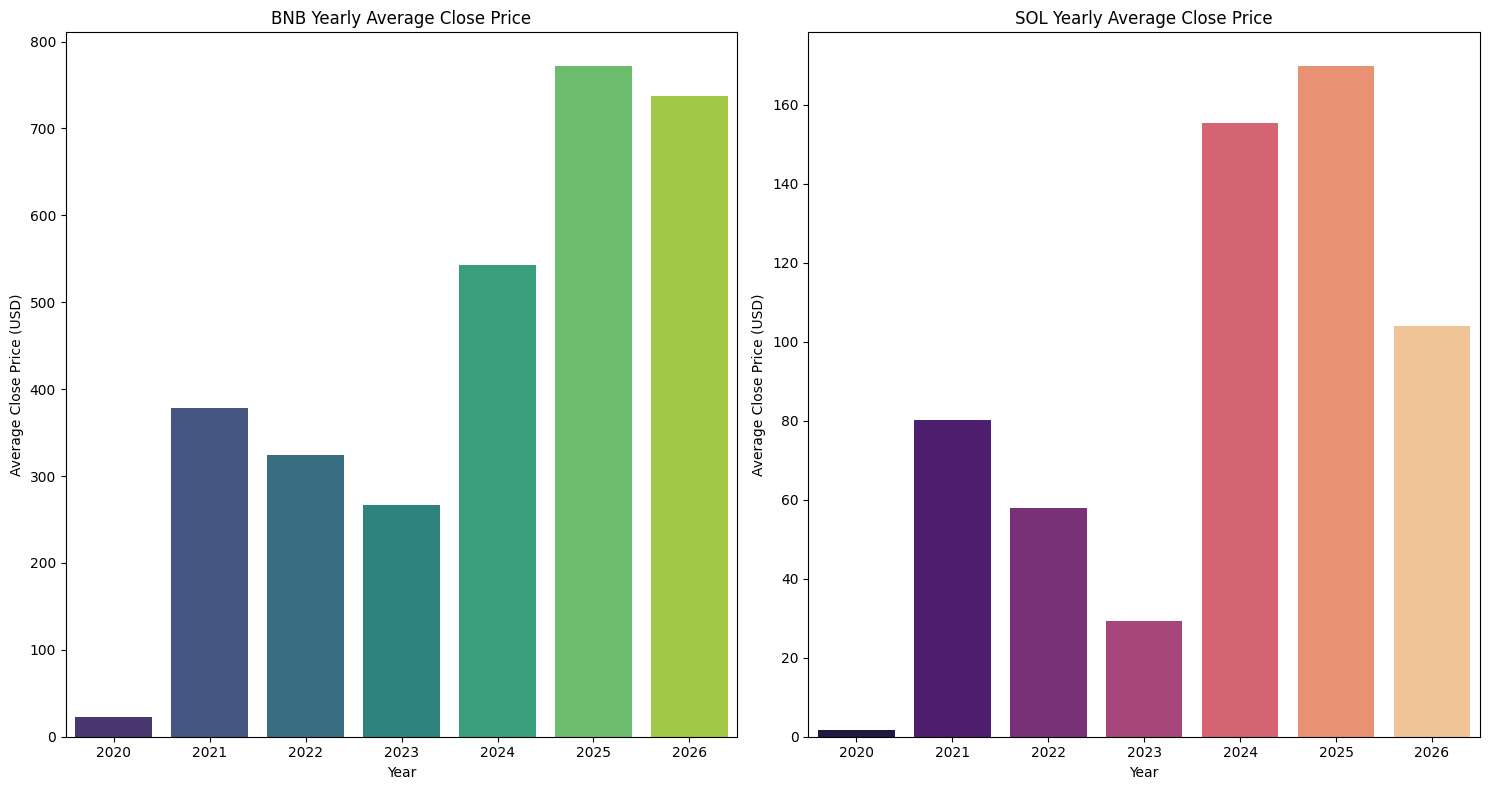

In [141]:
df4['date'] = pd.to_datetime(df4['date'])
df5['date'] = pd.to_datetime(df5['date'])

df4['close'] = pd.to_numeric(df4['close'])
df5['close'] = pd.to_numeric(df5['close'])

df4_yearly_avg = df4.groupby(df4['date'].dt.year)['close'].mean().reset_index()
df5_yearly_avg = df5.groupby(df5['date'].dt.year)['close'].mean().reset_index()

df4_yearly_avg.rename(columns={'date': 'year'}, inplace=True)
df5_yearly_avg.rename(columns={'date': 'year'}, inplace=True)

plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
sns.barplot(x='year',data=df4_yearly_avg,y='close', palette='viridis')
plt.title("BNB Yearly Average Close Price")
plt.xlabel("Year")
plt.ylabel("Average Close Price (USD)")

plt.subplot(1,2,2)
sns.barplot(x='year',data=df5_yearly_avg,y='close', palette='magma')
plt.title("SOL Yearly Average Close Price")
plt.xlabel("Year")
plt.ylabel("Average Close Price (USD)")

plt.tight_layout()
plt.show()

In [149]:
for year in [2020, 2021, 2022, 2023, 2024,2025]:
    bnb_year = df4[df4['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=bnb_year['date'],
        open=bnb_year['open'],
        high=bnb_year['high'],
        low=bnb_year['low'],
        close=bnb_year['close']
    )])

    fig.update_layout(title=f'BNB Candlestick Chart - {year}')
    fig.show()

In [150]:
for year in [2020, 2021, 2022, 2023, 2024,2025]:
    sol5_year = df5[df5['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=sol5_year['date'],
        open=sol5_year['open'],
        high=sol5_year['high'],
        low=sol5_year['low'],
        close=sol5_year['close']
    )])

    fig.update_layout(title=f'SOL Candlestick Chart - {year}')
    fig.show()

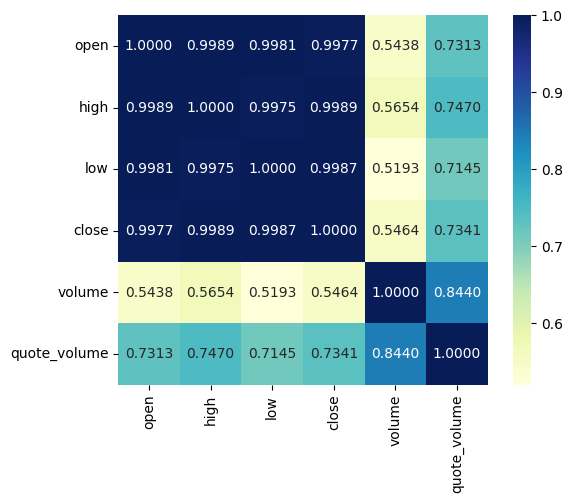

In [151]:
corr4=df4[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr4,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

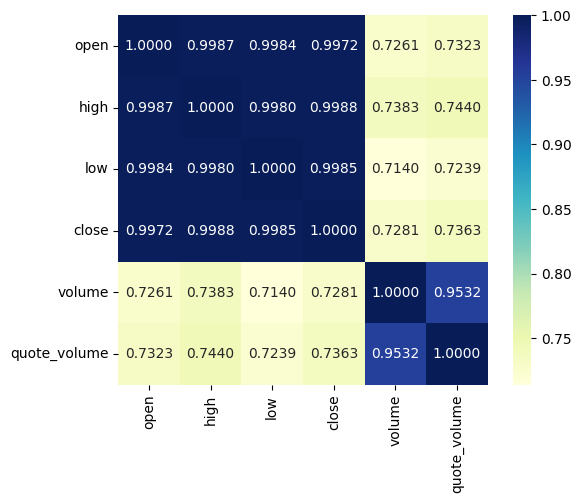

In [152]:
corr5=df5[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr5,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

### **Feature Engineering**

In [156]:
df4['open'] = pd.to_numeric(df4['open'])
df5['open'] = pd.to_numeric(df5['open'])
df4['candle_body']=df4['close']-df4['open']
df5['candle_body']=df5['close']-df5['open']

In [159]:
df4['high'] = pd.to_numeric(df4['high'])
df4['low'] = pd.to_numeric(df4['low'])
df5['high'] = pd.to_numeric(df5['high'])
df5['low'] = pd.to_numeric(df5['low'])
df4['high_low_range']=df4['high']-df4['low']
df5['high_low_range']=df5['high']-df5['low']

In [160]:
df4['MA_7']=df4['close'].rolling(window=7).mean()
df5['MA_7']=df5['close'].rolling(window=7).mean()

In [161]:
df4['MA_30']=df4['close'].rolling(window=30).mean()
df5['MA_30']=df5['close'].rolling(window=30).mean()

In [162]:
df4['moving_1d']=(df4['close']-df4['close'].shift(1))/df4['close'].shift(1) * 100
df5['moving_1d']=(df5['close']-df5['close'].shift(1))/df5['close'].shift(1) * 100

In [163]:
df4["volatility_7"] = df4["moving_1d"].rolling(window=7).std()
df5["volatility_7"] = df5["moving_1d"].rolling(window=7).std()

In [166]:
df4['volume'] = pd.to_numeric(df4['volume'])
df5['volume'] = pd.to_numeric(df5['volume'])
df4["volume_MA7"] = df4["volume"].rolling(window=7).mean()
df4["volumelast7"] = df4["volume"] / df4["volume_MA7"]
df5["volume_MA7"] = df5["volume"].rolling(window=7).mean()
df5["volumelast7"] = df5["volume"] / df5["volume_MA7"]

In [168]:
df4.drop(columns='volume_MA7',inplace=True)
df5.drop(columns='volume_MA7',inplace=True)

In [169]:
df4["rolling_mean_30"] = df4["close"].rolling(window=30).mean()
df4["rolling_std_30"]  = df4["close"].rolling(window=30).std()
df4["z_score"] = (df4["close"] - df4["rolling_mean_30"]) / df4["rolling_std_30"]

In [170]:
df5["rolling_mean_30"] = df5["close"].rolling(window=30).mean()
df5["rolling_std_30"]  = df5["close"].rolling(window=30).std()
df5["z_score"] = (df5["close"] - df5["rolling_mean_30"]) / df5["rolling_std_30"]

In [171]:
df4.drop(columns='rolling_mean_30',inplace=True)
df4.drop(columns='rolling_std_30',inplace=True)
df5.drop(columns='rolling_mean_30',inplace=True)
df5.drop(columns='rolling_std_30',inplace=True)

In [173]:
df4['tomorrow_close'] = df4['close'].shift(-1)
df4['tomorrow_return'] = (df4['tomorrow_close'] - df4['close']) / df4['close'] * 100

df4.head()

,date,close,high,low,open,volume,type,quote_volume,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-03-24,12.401220,12.571411,11.850914,12.116398,333522129,BNB,4.136081e+09,0.284822,0.720497,NaN,NaN,NaN,NaN,NaN,NaN,12.324300,-0.620266
1,2020-03-25,12.324300,12.630493,12.119498,12.403792,288895593,BNB,3.560436e+09,-0.079493,0.510995,NaN,NaN,-0.620266,NaN,NaN,NaN,13.217611,7.248375
2,2020-03-26,13.217611,13.217611,12.261119,12.325833,299218749,BNB,3.954957e+09,0.891778,0.956492,NaN,NaN,7.248375,NaN,NaN,NaN,12.523257,-5.253249
3,2020-03-27,12.523257,13.279883,12.507500,13.221527,263730266,BNB,3.302762e+09,-0.698270,0.772384,NaN,NaN,-5.253249,NaN,NaN,NaN,12.193113,-2.636246
4,2020-03-28,12.193113,12.533892,11.815067,12.533824,256061862,BNB,3.122191e+09,-0.340711,0.718824,NaN,NaN,-2.636246,NaN,NaN,NaN,11.441221,-6.166531


In [174]:
df5['tomorrow_close'] = df5['close'].shift(-1)
df5['tomorrow_return'] = (df5['tomorrow_close'] - df5['close']) / df5['close'] * 100

df5.head()

,date,close,high,low,open,volume,type,quote_volume,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-04-10,0.951054,1.313487,0.694187,0.832005,87364276,SOL,8.308814e+07,0.119049,0.619300,NaN,NaN,NaN,NaN,NaN,NaN,0.776819,-18.320200
1,2020-04-11,0.776819,1.049073,0.765020,0.951054,43862444,SOL,3.407318e+07,-0.174235,0.284053,NaN,NaN,-18.320200,NaN,NaN,NaN,0.882507,13.605233
2,2020-04-12,0.882507,0.956670,0.762426,0.785448,38736897,SOL,3.418558e+07,0.097059,0.194244,NaN,NaN,13.605233,NaN,NaN,NaN,0.777832,-11.861102
3,2020-04-13,0.777832,0.891603,0.773976,0.890760,18211285,SOL,1.416532e+07,-0.112928,0.117627,NaN,NaN,-11.861102,NaN,NaN,NaN,0.661925,-14.901284
4,2020-04-14,0.661925,0.796472,0.628169,0.777832,16747614,SOL,1.108566e+07,-0.115907,0.168303,NaN,NaN,-14.901284,NaN,NaN,NaN,0.646651,-2.307510
